In [3]:
# --- Setup -------------------------------------------------------------
import requests, pandas as pd
import matplotlib.pyplot as plt

GBIF = "https://api.gbif.org/v1"
TAXON_KEY = 2420694                      # Carcharodon carcharias on GBIF
HEADERS = {"User-Agent": "ProjectPlatypus-proof/1.0"}

def gbif(path, **params):
    r = requests.get(f"{GBIF}{path}", params=params, headers=HEADERS, timeout=60)
    r.raise_for_status()
    return r.json()

print("Ready. Target species: Carcharodon carcharias  (GBIF taxonKey =", TAXON_KEY, ")")

Ready. Target species: Carcharodon carcharias  (GBIF taxonKey = 2420694 )


In [4]:
sp = gbif(f"/species/{TAXON_KEY}")
print("Scientific name :", sp.get("scientificName"))
print("Canonical name  :", sp.get("canonicalName"))
print("Rank            :", sp.get("rank"))
print("Taxonomic status:", sp.get("taxonomicStatus"))

vern = gbif(f"/species/{TAXON_KEY}/vernacularNames").get("results", [])
english = [v["vernacularName"] for v in vern if v.get("language") == "eng"][:5]
print("English names   :", ", ".join(dict.fromkeys(english)))


Scientific name : Carcharodon carcharias (Linnaeus, 1758)
Canonical name  : Carcharodon carcharias
Rank            : SPECIES
Taxonomic status: ACCEPTED
English names   : 


In [5]:
facet = gbif("/occurrence/search", taxonKey=TAXON_KEY,
             hasCoordinate="true", limit=0,
             facet="country", facetLimit=15)["facets"]

rows = facet[0]["counts"] if facet else []

# GBIF returns ISO country codes; map the ones we care about to readable names
ISO = {"AU":"Australia","ZA":"South Africa","US":"United States (NE Pacific)",
       "NZ":"New Zealand","MX":"Mexico","IT":"Italy (Mediterranean)",
       "ES":"Spain","GB":"United Kingdom","PT":"Portugal","FR":"France",
       "HR":"Croatia","GR":"Greece","CL":"Chile","NC":"New Caledonia"}

df = pd.DataFrame(rows).rename(columns={"name":"iso","count":"records"})
df["region"] = df["iso"].map(ISO).fillna(df["iso"])
df = df[["region","iso","records"]]
df.index = range(1, len(df)+1)
display(df)

print("\nTop-5 regions to put on the slide-4 chart:")
for _, r in df.head(5).iterrows():
    print(f"  {r['region']:<28} {r['records']:>7,}")

,region,iso,records
1,Australia,AU,11315
2,United States (NE Pacific),US,3039
3,New Zealand,NZ,1743
4,CA,CA,654
5,BR,BR,378
6,South Africa,ZA,339
7,New Caledonia,NC,150
8,Mexico,MX,129
9,NF,NF,129
10,United Kingdom,GB,47



Top-5 regions to put on the slide-4 chart:
  Australia                     11,315
  United States (NE Pacific)     3,039
  New Zealand                    1,743
  CA                               654
  BR                               378


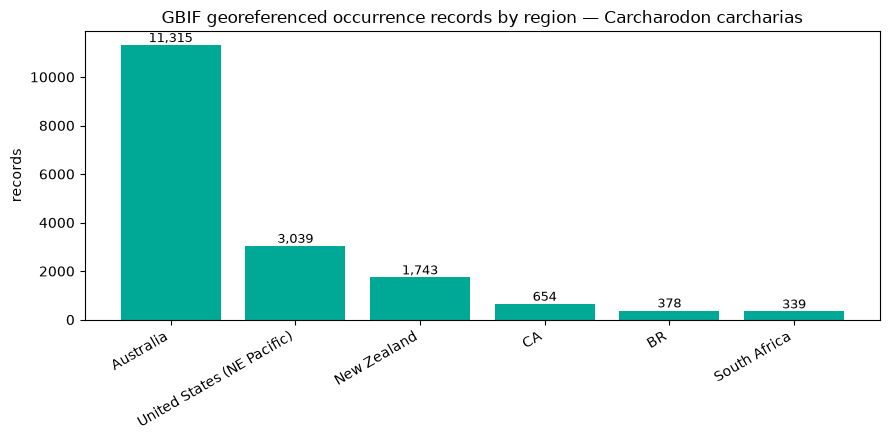

In [6]:
top = df.head(6)
plt.figure(figsize=(9,4.5))
plt.bar(top["region"], top["records"], color="#00A896")
plt.title("GBIF georeferenced occurrence records by region — Carcharodon carcharias")
plt.ylabel("records")
plt.xticks(rotation=30, ha="right")
for i, v in enumerate(top["records"]):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

In [7]:
dist = gbif(f"/species/{TAXON_KEY}/distributions").get("results", [])
iucn = [d for d in dist if str(d.get("source","")).upper().find("IUCN") >= 0
        or d.get("threatStatus")]
statuses = sorted({d.get("threatStatus") for d in dist if d.get("threatStatus")})
print("Threat statuses recorded in GBIF distributions:", statuses or "none returned")
print()
print("Expected: VULNERABLE  (matches slide 3 'Vulnerable — IUCN Red List global status')")
if not statuses:
    print("\nIf empty, GBIF didn't attach a status to this record set — rely on the")
    print("IUCN citation in the next cell, which is the authoritative source anyway.")

Threat statuses recorded in GBIF distributions: ['VULNERABLE']

Expected: VULNERABLE  (matches slide 3 'Vulnerable — IUCN Red List global status')


In [8]:
iucn_citation = {
    "Species": "Carcharodon carcharias (White Shark / Great White Shark)",
    "IUCN global status": "Vulnerable (VU) — criterion A2bd",
    "Subpopulation notes": "Critically Endangered (CR) in the Mediterranean and Europe",
    "Generation length": "53 years (IUCN Red List, Habitat & Ecology)",
    "Assessment": "Rigby, C.L. et al. 2022 (amended 2019 assessment)",
    "Red List ID": "e.T3855A212629880",
    "Direct URL": "https://www.iucnredlist.org/species/3855/2878674",
}
for k, v in iucn_citation.items():
    print(f"{k:<22}: {v}")


Species               : Carcharodon carcharias (White Shark / Great White Shark)
IUCN global status    : Vulnerable (VU) — criterion A2bd
Subpopulation notes   : Critically Endangered (CR) in the Mediterranean and Europe
Generation length     : 53 years (IUCN Red List, Habitat & Ecology)
Assessment            : Rigby, C.L. et al. 2022 (amended 2019 assessment)
Red List ID           : e.T3855A212629880
Direct URL            : https://www.iucnredlist.org/species/3855/2878674


In [9]:
summary = pd.DataFrame([
    ["Slide 3", "Vulnerable (IUCN)",            "GBIF distribution + IUCN citation (cell 4 & 5)"],
    ["Slide 3", "53-year generation length",    "IUCN Red List citation (cell 5)"],
    ["Slide 3", "6 m+ mature female length",    "IUCN assessment / species literature (cited)"],
    ["Slide 3", "All oceans, temperate",        "GBIF global occurrence spread (cell 3)"],
    ["Slide 4", "~38,000 occurrences",          "GBIF live count (cell 2)"],
    ["Slide 4", "Per-region counts",            "GBIF country facet — live (cell 3)"],
    ["Slide 4", "IUCN + EPBC cross-check",       "GBIF status mirror + gov. listings"],
], columns=["Slide", "Claim", "How it's proven"])
summary.index = range(1, len(summary)+1)
display(summary)


,Slide,Claim,How it's proven
1,Slide 3,Vulnerable (IUCN),GBIF distribution + IUCN citation (cell 4 & 5)
2,Slide 3,53-year generation length,IUCN Red List citation (cell 5)
3,Slide 3,6 m+ mature female length,IUCN assessment / species literature (cited)
4,Slide 3,"All oceans, temperate",GBIF global occurrence spread (cell 3)
5,Slide 4,"~38,000 occurrences",GBIF live count (cell 2)
6,Slide 4,Per-region counts,GBIF country facet — live (cell 3)
7,Slide 4,IUCN + EPBC cross-check,GBIF status mirror + gov. listings
